In [4]:
from random import sample

import pandas as pd
df_filtered = pd.read_csv('user_survey_1.csv',header=None)
df_filtered.columns = ['id', 'uuid', 'q', 'answer']
#print (df)

dummy_uuid = ['a3af6958-a14e-4c88-881f-9694c40fccbc', 'd35f771e-f4be-403b-90da-eb0e61790007']

df = df_filtered[~df_filtered['uuid'].isin(dummy_uuid)]

df1 = pd.read_csv('../../../survey/questions.csv')
Qid = ['Q' + str(i+1) for i in range(20)]
df1['q'] = Qid
df1 = df1[['Real Persona','q']]
#print (df1)

def match(x, y):
    if x == y:
        return 1
    elif x == "Subject Matter Expert" and "Both" in y:
        return 0.5
    elif x == "Data Scientist" and "Both" in y:
        return 0.5
    else:
        return 0

merged_table = df.merge(df1, on='q')
print (merged_table)
merged_table['binary'] = merged_table.apply(lambda row: match(row['answer'], row['Real Persona']), axis=1)
print (merged_table['binary'].sum()/300)
print (merged_table.columns)
'''
print (merged_table)

selected_q = ['Q1','Q2','Q3','Q4','Q5','Q6','Q7']
merged_table['subset'] = merged_table['q'].apply(lambda x: 0 if x in selected_q else 1)
merged_table = merged_table[merged_table['subset']==1]
print (merged_table['binary'].sum())

# question wise correctness
print (merged_table.groupby('q').sum('binary'))

# userwise wise correctness
print (merged_table.groupby('uuid').sum('binary'))

merged_table['annotator_1'] = merged_table['binary']
merged_table['annotator_2'] = merged_table['binary'].sample(frac=1).reset_index(drop=True)  # Simulating a different annotator

# Calculate tie-discounted accuracy with partial agreement
total_weighted_agreement = 0
total_pairs = 0

for response_1, response_2 in zip(merged_table['annotator_1'], merged_table['annotator_2']):
    if response_1 == response_2:
        total_weighted_agreement += 1
    else:
        weight = min(response_1, response_2)
        total_weighted_agreement += weight
    total_pairs += 1

tie_discounted_accuracy = total_weighted_agreement / total_pairs * 100

print(f'Tie-Discounted Accuracy (with partial agreement): {tie_discounted_accuracy:.2f}%')
'''

      id                                  uuid    q                 answer  \
0      1  2b62b03e-5cbf-4dc7-9a57-90c2c411f59c   Q1          Both DS & SME   
1     21  f5343f6a-d5e2-46a8-81de-9550106a55d2   Q1          Both DS & SME   
2     41  885db72c-222e-4560-9ebe-b795bffdcdf3   Q1          Both DS & SME   
3     61  a9eed7aa-d46f-4e7c-9803-8cc5ad7ec3ef   Q1          Both DS & SME   
4     81  6db8ea28-5780-47bd-9d62-90e445f78061   Q1  Subject Matter Expert   
..   ...                                   ...  ...                    ...   
295  220  ca2dc038-a394-493a-8e2d-f6d2029773a5  Q20         Data Scientist   
296  240  48b9c802-a224-4012-a7dc-f961b233eb2b  Q20         Data Scientist   
297  260  a72cdc83-f895-4ae9-af65-90dfbe25deab  Q20         Data Scientist   
298  300  0a61c6bd-2d62-4d59-b290-e357aa5dd1b0  Q20          Both DS & SME   
299  340  3582c4ce-d8df-47d0-a387-7dfae14377a8  Q20         Data Scientist   

       Real Persona  
0     Both DS & SME  
1     Both DS & SME

"\nprint (merged_table)\n\nselected_q = ['Q1','Q2','Q3','Q4','Q5','Q6','Q7']\nmerged_table['subset'] = merged_table['q'].apply(lambda x: 0 if x in selected_q else 1)\nmerged_table = merged_table[merged_table['subset']==1]\nprint (merged_table['binary'].sum())\n\n# question wise correctness\nprint (merged_table.groupby('q').sum('binary'))\n\n# userwise wise correctness\nprint (merged_table.groupby('uuid').sum('binary'))\n\nmerged_table['annotator_1'] = merged_table['binary']\nmerged_table['annotator_2'] = merged_table['binary'].sample(frac=1).reset_index(drop=True)  # Simulating a different annotator\n\n# Calculate tie-discounted accuracy with partial agreement\ntotal_weighted_agreement = 0\ntotal_pairs = 0\n\nfor response_1, response_2 in zip(merged_table['annotator_1'], merged_table['annotator_2']):\n    if response_1 == response_2:\n        total_weighted_agreement += 1\n    else:\n        weight = min(response_1, response_2)\n        total_weighted_agreement += weight\n    total_pai

In [6]:
import pandas as pd

# Assuming df is your DataFrame
# Group by the 'q' column and calculate the mean of the 'binary' column for each group
grouped_df = merged_table.groupby('q')['binary'].mean().reset_index()

# Sort the groups based on the mean values
sorted_df = grouped_df.sort_values(by='binary', ascending=False)

# Select the top 3 and bottom 3 groups
top_3 = sorted_df.head(3)['q'].tolist()
bottom_3 = sorted_df.tail(3)['q'].tolist()

print("Top 3 distinct q with highest values:", top_3)
print("Bottom 3 distinct q with lowest values:", bottom_3)


Top 3 distinct q with highest values: ['Q9', 'Q13', 'Q10']
Bottom 3 distinct q with lowest values: ['Q14', 'Q15', 'Q17']


In [9]:
values_to_select = ['Q9', 'Q13', 'Q10', 'Q14', 'Q15', 'Q17']

# Filter the DataFrame to include only the rows where the value in the 'q' column matches one of the values in values_to_select
filtered_df = merged_table[merged_table['q'].isin(values_to_select)]

In [10]:
filtered_df

,id,uuid,q,answer,Real Persona,binary
120,9,2b62b03e-5cbf-4dc7-9a57-90c2c411f59c,Q9,Subject Matter Expert,Subject Matter Expert,1.0
121,29,f5343f6a-d5e2-46a8-81de-9550106a55d2,Q9,Subject Matter Expert,Subject Matter Expert,1.0
122,49,885db72c-222e-4560-9ebe-b795bffdcdf3,Q9,Subject Matter Expert,Subject Matter Expert,1.0
123,69,a9eed7aa-d46f-4e7c-9803-8cc5ad7ec3ef,Q9,Data Scientist,Subject Matter Expert,0.0
124,89,6db8ea28-5780-47bd-9d62-90e445f78061,Q9,Subject Matter Expert,Subject Matter Expert,1.0
...,...,...,...,...,...,...
250,217,ca2dc038-a394-493a-8e2d-f6d2029773a5,Q17,Subject Matter Expert,Data Scientist,0.0
251,237,48b9c802-a224-4012-a7dc-f961b233eb2b,Q17,Subject Matter Expert,Data Scientist,0.0
252,257,a72cdc83-f895-4ae9-af65-90dfbe25deab,Q17,Subject Matter Expert,Data Scientist,0.0
253,297,0a61c6bd-2d62-4d59-b290-e357aa5dd1b0,Q17,Subject Matter Expert,Data Scientist,0.0


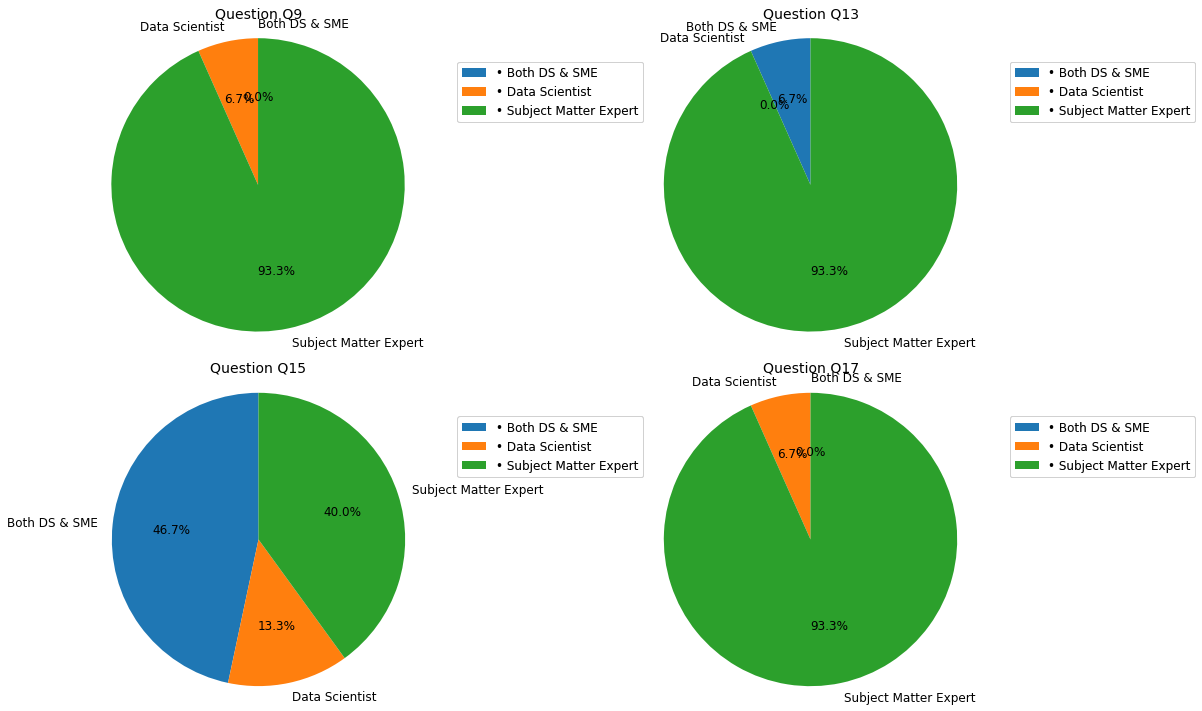

In [50]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
# Group the DataFrame by the 'q' column
grouped_df = filtered_df.groupby('q')['answer'].value_counts().unstack(fill_value=0)

# Define colors for the pie charts
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Create a 2x2 grid of pie charts with white background
fig, axs = plt.subplots(2, 2, figsize=(15, 10), facecolor='white')

# Plot a pie chart for each question
for i, question in enumerate(['Q9', 'Q13']):
    ax = axs[0, i]
    wedges, texts, autotexts = ax.pie(grouped_df.loc[question], labels=grouped_df.columns, autopct='%1.1f%%', startangle=90, colors=colors, textprops={'fontsize': 12})
    ax.set_title(f'Question {question}', fontdict={'fontsize': 14})
    ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
    
    # Create a legend as a bullet-point list
    bullet_points = ['\u2022 ' + label for label in grouped_df.columns]
    legend = ax.legend(bullet_points, loc='upper left', bbox_to_anchor=(0.9, 0.9), fontsize=12)
    ax.add_artist(legend)

# Plot the remaining questions in the second row
for i, question in enumerate(['Q15', 'Q17']):
    ax = axs[1, i]
    wedges, texts, autotexts = ax.pie(grouped_df.loc[question], labels=grouped_df.columns, autopct='%1.1f%%', startangle=90, colors=colors, textprops={'fontsize': 12})
    ax.set_title(f'Question {question}', fontdict={'fontsize': 14})
    ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
    
    # Create a legend as a bullet-point list
    bullet_points = ['\u2022 ' + label for label in grouped_df.columns]
    legend = ax.legend(bullet_points, loc='upper left', bbox_to_anchor=(0.9, 0.9), fontsize=12)
    ax.add_artist(legend)

# Adjust layout
plt.tight_layout()

# Save the image as a PNG file
plt.savefig('pie_chart.png', bbox_inches='tight')

plt.show()


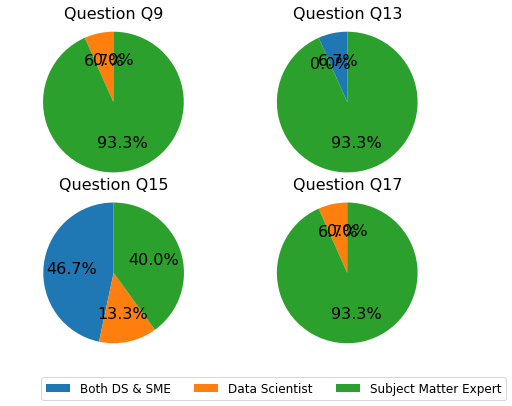

In [66]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming df is your DataFrame
# Group the DataFrame by the 'q' column
grouped_df = filtered_df.groupby('q')['answer'].value_counts().unstack(fill_value=0)

# Define colors for the pie charts
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# Create a 2x2 grid of pie charts with white background
fig, axs = plt.subplots(2, 2, figsize=(8, 6), facecolor='white')

# Plot a pie chart for each question
for i, question in enumerate(['Q9', 'Q13']):
    ax = axs[0, i]
    wedges, texts, autotexts = ax.pie(grouped_df.loc[question], autopct='%1.1f%%', startangle=90, colors=colors, textprops={'fontsize': 16})
    ax.set_title(f'Question {question}', fontdict={'fontsize': 16})
    ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

# Plot the remaining questions in the second row
for i, question in enumerate(['Q15', 'Q17']):
    ax = axs[1, i]
    wedges, texts, autotexts = ax.pie(grouped_df.loc[question], autopct='%1.1f%%', startangle=90, colors=colors, textprops={'fontsize': 16})
    ax.set_title(f'Question {question}', fontdict={'fontsize': 16})
    ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

# Create a common legend
legend_labels = grouped_df.columns
fig.legend(legend_labels, loc='lower right', ncol=len(legend_labels), fontsize=12)

# Adjust layout to bring subplots closer
plt.subplots_adjust(hspace=0.1, wspace=0.1)

# Save the image as a PNG file
plt.savefig('piechart.png', bbox_inches='tight')

plt.show()
